# Section 5 — Figure 5G: KSHV/CD34⁺ spacetime infection-density trends (2×2 by niche group)

In [ ]:
import scanpy as sc

DATA_PATH = '../data/KS_adata_preprocessed.h5ad'

adata = sc.read_h5ad(DATA_PATH)
adata.obsm["spatial"] = adata.obs[["local_x", "local_y"]].copy().to_numpy()
print("loaded:", DATA_PATH, "| cells:", adata.n_obs, "| genes:", adata.n_vars)

KS_lytic_genes  = ['KSHV.ORF50', 'KSHV.ORF57', 'KSHV.ORF59', 'KSHV.K9', 'KSHV.ORF65']
KS_latent_genes = ['KSHV.ORF71', 'KSHV.ORF72', 'KSHV.ORF73']
KS_K2_gene      = ['KSHV.K2']

[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    2.5s


[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    2.9s


[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    3.2s


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    3.6s


[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    4.1s


...

[Parallel(n_jobs=-1)]: Done 256 out of 256 | elapsed:    5.2s finished


  Combining results...


  ✓ Saved: intermediate_results/density_optimized_with_all.parquet
  ✓ Computed 42 density columns for 5,830,817 cells


  ✓ Added 42 density columns to adata.obs


Sample order length: 256


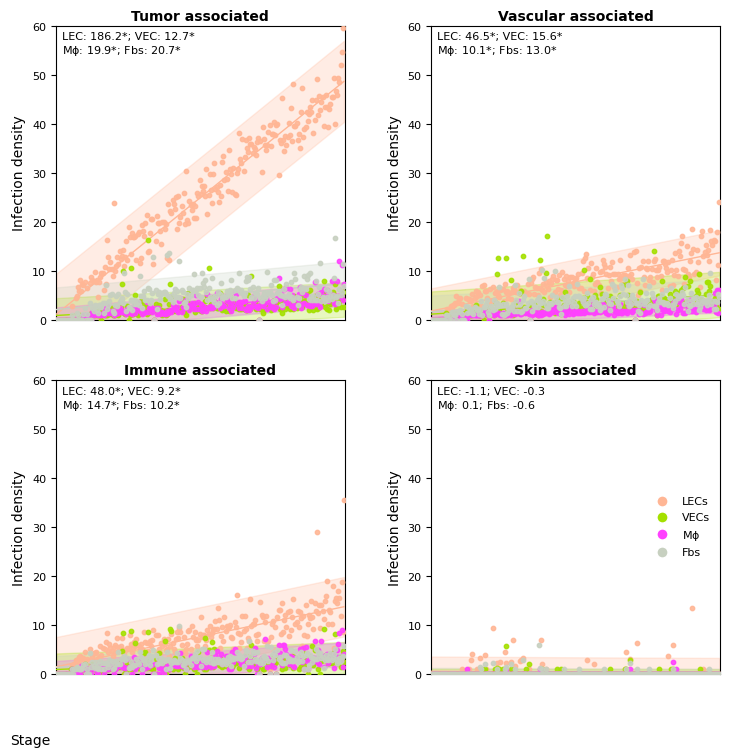

Saved: ../figures/spacetime/top_only_infected_2x2_overview_cd34pos_v2.pdf


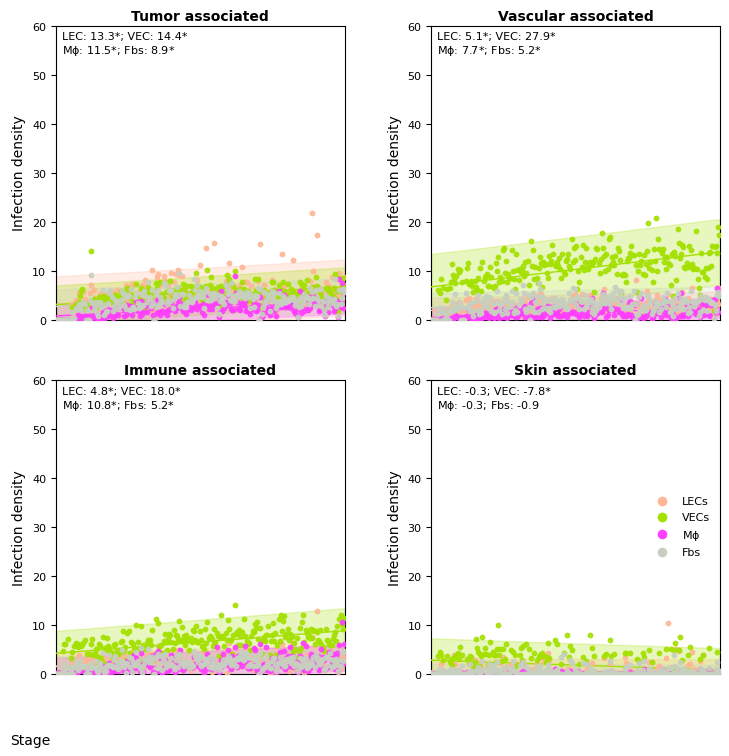

Saved: ../figures/spacetime/top_only_uninfected_2x2_overview_cd34pos_v2.pdf
=== Trend stats for [infected] niche group: tumor_associated ===
  Lymphatic Endothelial Cells    -> slope (b1) = 0.1862, p-value = 6.212e-139, CI = [0.1793, 0.1932]
  Vascular Endothelial Cells     -> slope (b1) = 0.0127, p-value = 2.221e-15, CI = [0.0098, 0.0157]
  Macrophages                    -> slope (b1) = 0.0199, p-value = 2.572e-53, CI = [0.0179, 0.0219]
  Fibroblasts                    -> slope (b1) = 0.0207, p-value = 2.146e-22, CI = [0.0169, 0.0245]

=== Trend stats for [infected] niche group: vascular_stroma ===
  Lymphatic Endothelial Cells    -> slope (b1) = 0.0465, p-value = 6.427e-66, CI = [0.0426, 0.0503]
  Vascular Endothelial Cells     -> slope (b1) = 0.0156, p-value = 9.466e-14, CI = [0.0117, 0.0195]
  Macrophages                    -> slope (b1) = 0.0101, p-value = 1.066e-38, CI = [0.0088, 0.0114]
  Fibroblasts                    -> slope (b1) = 0.0130, p-value = 7.943e-18, CI = [0.0103, 0

In [ ]:
# ============================================================
# OPTION 2 TREND PLOT: COMPLETE SELF-CONTAINED VERSION
# ============================================================
# - Simplified titles (e.g., "Tumor associated")
# - Slope statistics as text annotation inside plot (upper left)
# - Legend only in bottom-right subplot (right-center aligned)
# - Stage color bar at bottom of each column
# - Y-axis: "Infection density"
# - Stage colors match Figure 4I and other figures
# - ALL DEPENDENCIES INCLUDED (no external imports)
# ============================================================

import os
import re
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
import scipy.sparse as sp

from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# Matplotlib defaults
# -----------------------------
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['pdf.fonttype']     = 42
plt.rcParams['ps.fonttype']      = 42
plt.rcParams['font.size']        = 8

# -----------------------------
# Constants
# -----------------------------
RADIUS_UM = 10.0
PIXEL_PER_UM = 1 / 0.2125
RADIUS_PX = RADIUS_UM * PIXEL_PER_UM

INTERMEDIATE_DIR = "intermediate_results"
FIGURES_DIR = "../figures/spacetime"

# -----------------------------
# Label dictionaries
# -----------------------------
SLOPE_LABELS = {
    'Lymphatic Endothelial Cells':   'LEC',
    'Vascular Endothelial Cells':    'VEC',
    'Fibroblasts':                   'Fbs',
    'Macrophages':                   r'M$\phi$',
}

LEGEND_LABELS = {
    'Lymphatic Endothelial Cells':   'LECs',
    'Vascular Endothelial Cells':    'VECs',
    'Fibroblasts':                   'Fbs',
    'Macrophages':                   r'M$\phi$',
}

NICHE_DISPLAY_NAMES = {
    'tumor_associated':   'Tumor associated',
    'vascular_stroma':    'Vascular associated',
    'immune_stroma':      'Immune associated',
    'skin_associated':    'Skin associated',
}

CELL_TYPES_COLOR_DICT_TREND = {
    'Lymphatic Endothelial Cells': '#ffb695',
    'Macrophages':                 '#ff40ff',
    'Vascular Endothelial Cells':  '#a4e000',
    'Fibroblasts':                 '#c7d0c0',
}

# Stage colors - MATCHES Figure 4I and other figures
STAGE_COLORS = {
    "nodular": "#ed322f",   # red
    "plaque":  "#ffdc5e",   # yellow
    "patch":   "#51f512",   # green
    "control": "blue",      # blue
}

# Y-axis columns (KSHV+ CD34+ neighbor density)
CELL_TYPES_AND_COLS_INFECTED_TREND = {
    'Lymphatic Endothelial Cells': 'density_infected_CD34_pos_Lymphatic_Endothelial_Cells',
    'Vascular Endothelial Cells':  'density_infected_CD34_pos_Vascular_Endothelial_Cells',
    'Macrophages':                 'density_infected_CD34_pos_Macrophages',
    'Fibroblasts':                 'density_infected_CD34_pos_Fibroblasts',
}

CELL_TYPES_AND_COLS_UNINFECTED_TREND = {
    ct: col.replace('infected', 'uninfected')
    for ct, col in CELL_TYPES_AND_COLS_INFECTED_TREND.items()
}

CELL_TYPE_ORDER = [
    'Lymphatic Endothelial Cells',
    'Vascular Endothelial Cells',
    'Macrophages',
    'Fibroblasts',
]

TUMORAL_NICHES = ["Tumor Core", "Tumor", "Tumor Boundary"]

BROAD_CELL_TYPES = [
    "Lymphatic Endothelial Cells",
    "Vascular Endothelial Cells",
    "Macrophages",
    "Fibroblasts",
    "T-cells",
    "Dendritic cells",
]


# ============================================================
# IO / CACHE UTILS
# ============================================================

def ensure_dirs() -> None:
    os.makedirs(INTERMEDIATE_DIR, exist_ok=True)
    os.makedirs(FIGURES_DIR, exist_ok=True)

def _parquet_path(name: str) -> str:
    return f"{INTERMEDIATE_DIR}/{name}.parquet"

def save_intermediate(df: pd.DataFrame, name: str) -> None:
    ensure_dirs()
    df.to_parquet(_parquet_path(name))
    print(f"  ✓ Saved: {_parquet_path(name)}")

def load_intermediate(name: str) -> pd.DataFrame:
    path = _parquet_path(name)
    df = pd.read_parquet(path)
    print(f"  ✓ Loaded: {path} (shape: {df.shape})")
    return df

def check_intermediate_exists(name: str) -> bool:
    return os.path.exists(_parquet_path(name))


# ============================================================
# CD34 STATUS
# ============================================================

def add_cd34_status(
    adata,
    cd34_gene: str = "CD34",
    cd34_status_col: str = "CD34_status",
) -> None:
    """Add CD34 status column to adata.obs."""
    
    if cd34_status_col in adata.obs.columns:
        print(f"  {cd34_status_col} already exists, skipping...")
        return
    
    if cd34_gene not in adata.var_names:
        raise ValueError(f"Gene '{cd34_gene}' not found.")
    
    X_cd34 = adata[:, cd34_gene].X
    if sp.issparse(X_cd34):
        cd34_counts = np.asarray(X_cd34.todense()).ravel()
    else:
        cd34_counts = np.asarray(X_cd34).ravel()
    
    adata.obs[cd34_status_col] = np.where(cd34_counts > 0, "CD34+", "CD34-")
    
    print(f"  CD34 status: {(cd34_counts > 0).sum():,} CD34+ / {(cd34_counts == 0).sum():,} CD34-")
    
    if 'infection_status' in adata.obs.columns:
        infected = adata.obs['infection_status'] == 'infected'
        print(f"  Among KSHV+ cells: {(infected & (cd34_counts > 0)).sum():,} CD34+, "
              f"{(infected & (cd34_counts == 0)).sum():,} CD34-")


# ============================================================
# DENSITY COMPUTATION
# ============================================================

def _get_coords(adata) -> np.ndarray:
    """Extract coordinates from adata."""
    if "spatial" in adata.obsm:
        return adata.obsm["spatial"][:, :2]
    return adata.obs[["x_centroid", "y_centroid"]].values


def build_category_masks(
    obs: pd.DataFrame,
    infection_col: str,
    broad_cell_types: List[str],
) -> Dict[str, np.ndarray]:
    """Pre-compute ALL category masks globally."""
    masks = {}
    
    infected = (obs[infection_col] == 'infected').values
    uninfected = ~infected
    cd34_pos = (obs['CD34_status'] == 'CD34+').values
    cd34_neg = ~cd34_pos
    
    # Add "all" categories for overall density
    masks["infected_all"] = infected
    masks["uninfected_all"] = uninfected
    masks["infected_CD34_pos_all"] = infected & cd34_pos
    masks["infected_CD34_neg_all"] = infected & cd34_neg
    masks["uninfected_CD34_pos_all"] = uninfected & cd34_pos
    masks["uninfected_CD34_neg_all"] = uninfected & cd34_neg
    
    for ct in broad_cell_types:
        ct_mask = (obs['broad_cell_types'] == ct).values
        ct_key = ct.replace(" ", "_")
        
        masks[f"infected_{ct_key}"] = ct_mask & infected
        masks[f"infected_CD34_pos_{ct_key}"] = ct_mask & infected & cd34_pos
        masks[f"infected_CD34_neg_{ct_key}"] = ct_mask & infected & cd34_neg
        
        masks[f"uninfected_{ct_key}"] = ct_mask & uninfected
        masks[f"uninfected_CD34_pos_{ct_key}"] = ct_mask & uninfected & cd34_pos
        masks[f"uninfected_CD34_neg_{ct_key}"] = ct_mask & uninfected & cd34_neg
    
    return masks


def process_core_optimized(
    core: str,
    core_indices: np.ndarray,
    coords: np.ndarray,
    global_masks: Dict[str, np.ndarray],
    radius_px: float,
) -> Tuple[str, pd.DataFrame]:
    """Process single core with vectorized neighbor counting."""
    n = len(core_indices)
    core_coords = coords[core_indices]
    
    tree = cKDTree(core_coords)
    neighbors_list = tree.query_ball_point(core_coords, radius_px)
    
    row_indices = []
    col_indices = []
    for i, nbrs in enumerate(neighbors_list):
        if nbrs:
            row_indices.extend([i] * len(nbrs))
            col_indices.extend(nbrs)
    
    if not row_indices:
        result_cols = [f"density_{k}" for k in global_masks.keys()]
        return core, pd.DataFrame(0, index=core_indices, columns=result_cols)
    
    adj = csr_matrix(
        (np.ones(len(row_indices), dtype=np.float32), (row_indices, col_indices)),
        shape=(n, n)
    )
    
    results = {}
    for cat_name, global_mask in global_masks.items():
        core_mask = global_mask[core_indices].astype(np.float32)
        counts = adj.dot(core_mask)
        results[f"density_{cat_name}"] = counts
    
    result_df = pd.DataFrame(results, index=core_indices)
    return core, result_df


def compute_densities_optimized(
    adata,
    infection_col: str = "infection_status",
    radius_px: float = RADIUS_PX,
    broad_cell_types: List[str] = BROAD_CELL_TYPES,
    n_jobs: int = -1,
    force: bool = False,
    cache_name: str = "density_optimized_with_all",
) -> pd.DataFrame:
    """Compute densities with optimized parallel processing."""
    ensure_dirs()
    
    if not force and check_intermediate_exists(cache_name):
        return load_intermediate(cache_name)
    
    print("\n" + "=" * 60)
    print("COMPUTING DENSITIES (OPTIMIZED)")
    print("=" * 60)
    
    print("  Extracting coordinates...")
    coords = _get_coords(adata)
    
    print("  Building category masks...")
    global_masks = build_category_masks(adata.obs, infection_col, broad_cell_types)
    print(f"    Created {len(global_masks)} category masks")
    
    cores = adata.obs["path_block_core"].unique().tolist()
    print(f"  Processing {len(cores)} cores...")
    
    core_to_indices = {}
    obs_index = adata.obs.index.values
    core_labels = adata.obs["path_block_core"].values
    
    for core in cores:
        mask = core_labels == core
        core_to_indices[core] = np.where(mask)[0]
    
    results = Parallel(n_jobs=n_jobs, verbose=10, backend="loky")(
        delayed(process_core_optimized)(
            core,
            core_to_indices[core],
            coords,
            global_masks,
            radius_px,
        )
        for core in cores
    )
    
    print("  Combining results...")
    all_dfs = []
    for core, df in results:
        df.index = obs_index[df.index.values]
        all_dfs.append(df)
    
    combined = pd.concat(all_dfs, axis=0)
    combined = combined.reindex(adata.obs.index, fill_value=0)
    
    save_intermediate(combined, cache_name)
    
    print(f"  ✓ Computed {combined.shape[1]} density columns for {combined.shape[0]:,} cells")
    
    return combined


def add_densities_to_adata(adata, density_df: pd.DataFrame) -> None:
    """Add density columns to adata.obs."""
    existing = [c for c in density_df.columns if c in adata.obs.columns]
    if existing:
        adata.obs.drop(columns=existing, inplace=True, errors="ignore")
    
    aligned = density_df.reindex(adata.obs.index).fillna(0)
    for col in density_df.columns:
        adata.obs[col] = aligned[col].values
    
    print(f"  ✓ Added {len(density_df.columns)} density columns to adata.obs")


# ============================================================
# SAMPLE ORDERING
# ============================================================

def compute_sample_order_kshv_all_in_tumor(adata, tumoral_niches: List[str]) -> List[str]:
    """
    Core ordering:
      - Controls first (alphabetical core IDs)
      - Then non-control cores ordered by mean density_infected_all in tumoral niches
    """
    metric_col = "density_infected_all"
    if metric_col not in adata.obs.columns:
        raise KeyError(f"{metric_col} not found.")

    core_stages = (
        adata.obs.groupby("path_block_core", observed=True)["Stage"]
        .first().astype(str)
    )
    control_cores = sorted(core_stages[core_stages == "control"].index.tolist())
    noncontrol_cores = core_stages[core_stages != "control"].index.tolist()

    tumoral_mask = (
        adata.obs["niche_with_tumor_proximity"].isin(tumoral_niches) &
        adata.obs["path_block_core"].isin(noncontrol_cores)
    )

    means = (
        adata.obs.loc[tumoral_mask]
        .groupby("path_block_core", observed=True)[metric_col]
        .mean()
        .reindex(noncontrol_cores, fill_value=0.0)
    )

    noncontrol_sorted = means.sort_values(ascending=True).index.tolist()
    return control_cores + noncontrol_sorted


def get_core_stages(adata, sample_order: List[str]) -> pd.Series:
    """Get stage for each core in order."""
    core_stages = (
        adata.obs.groupby("path_block_core", observed=True)["Stage"]
        .first().astype(str)
    )
    return core_stages.reindex(sample_order)


# ============================================================
# TREND PLOT FUNCTION
# ============================================================

def plot_top_spacetime_for_subset(
    adata_subset,
    cell_types_and_cols: Dict[str, str],
    cell_types_color_dict: Dict[str, str],
    niche_group: str,
    ax: plt.Axes,
    sample_order_global: List[str],
    y_max: float = 60.0,
    show_legend: bool = False,
    slope_scale: float = 1.0,
) -> Dict[str, Tuple[float, float, float, float]]:
    """
    Trend plot for a subset adata with revised styling.
    
    Returns: {cell_type: (b1, pval, ci_lower, ci_upper)}
    """
    title_text = NICHE_DISPLAY_NAMES.get(niche_group, niche_group)
    
    if adata_subset.n_obs == 0:
        ax.text(
            0.5, 0.5, "No data",
            ha='center', va='center',
            fontsize=10, color='gray',
            transform=ax.transAxes
        )
        ax.set_title(title_text, fontsize=10, fontweight='bold', pad=4)
        ax.set_xticks([])
        ax.set_yticks([])
        return {}

    # Compute average densities per core
    avg_densities = {}
    for ct, col in cell_types_and_cols.items():
        obs_ct = adata_subset.obs[adata_subset.obs['broad_cell_types'] == ct]
        if obs_ct.empty or col not in obs_ct.columns:
            avg_densities[ct] = pd.Series(0.0, index=sample_order_global)
        else:
            df_means = (
                obs_ct.groupby('path_block_core', observed=True)[col]
                .mean()
                .fillna(0.0)
                .reindex(sample_order_global, fill_value=0.0)
            )
            avg_densities[ct] = df_means

    n_cols = len(sample_order_global)
    X = np.arange(n_cols)
    trend_stats = {}

    # Plot each cell type
    for ct in CELL_TYPE_ORDER:
        if ct not in cell_types_and_cols:
            continue
            
        Y = avg_densities[ct].values
        c = cell_types_color_dict.get(ct, 'black')
        
        # Scatter points
        ax.scatter(X, Y, color=c, s=10, alpha=0.9, zorder=4)

        if n_cols > 1 and not np.all(Y == 0):
            # OLS regression
            X_with_const = sm.add_constant(X)
            ols_model = sm.OLS(Y, X_with_const).fit()

            b1 = float(ols_model.params[1])
            pval = float(ols_model.pvalues[1])
            cov = ols_model.cov_params()
            se_b1 = float(np.sqrt(cov[1, 1]))

            df_resid = n_cols - 2
            t_crit = float(stats.t.ppf(0.975, df_resid))
            ci_lower = b1 - t_crit * se_b1
            ci_upper = b1 + t_crit * se_b1
            trend_stats[ct] = (b1, pval, ci_lower, ci_upper)

            # Prediction line and interval
            Y_pred = ols_model.predict(X_with_const)
            sigma_hat = float(np.sqrt(ols_model.mse_resid))
            X_mean = float(X.mean())
            SSx = float(np.sum((X - X_mean) ** 2))

            se_pred = sigma_hat * np.sqrt(1.0 + 1.0 / n_cols + ((X - X_mean) ** 2) / SSx)
            PI_upper = Y_pred + t_crit * se_pred
            PI_lower = Y_pred - t_crit * se_pred

            ax.plot(X, Y_pred, color=c, linestyle='-', linewidth=1, zorder=3)
            ax.fill_between(X, PI_lower, PI_upper, color=c, alpha=0.25, zorder=2)
        else:
            trend_stats[ct] = (0.0, np.nan, 0.0, 0.0)

    # Axes formatting
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(0, y_max)
    ax.set_xticks([])
    ax.set_ylabel('Infection density', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(title_text, fontsize=10, fontweight='bold', pad=4)

    # Slope annotation inside plot (upper left)
    def format_slope(ct):
        label = SLOPE_LABELS.get(ct, ct)
        if ct in trend_stats:
            b1, pval, _, _ = trend_stats[ct]
            slope_val = b1 * slope_scale
            star = '*' if (not np.isnan(pval) and pval < 0.05) else ''
            if abs(slope_val) >= 0.1:
                return f"{label}: {slope_val:.1f}{star}"
            else:
                return f"{label}: {slope_val:.2f}{star}"
        else:
            return f"{label}: 0.0"
    
    line1 = f"{format_slope('Lymphatic Endothelial Cells')}; {format_slope('Vascular Endothelial Cells')}"
    line2 = f"{format_slope('Macrophages')}; {format_slope('Fibroblasts')}"
    
    ax.text(
        0.02, 0.98,
        f"{line1}\n{line2}",
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        horizontalalignment='left',
        fontfamily='sans-serif',
    )

    # Legend (only for bottom-right subplot)
    if show_legend:
        legend_handles = []
        for ct in CELL_TYPE_ORDER:
            if ct in cell_types_and_cols:
                handle = plt.Line2D(
                    [0], [0],
                    marker='o',
                    color='w',
                    markerfacecolor=cell_types_color_dict.get(ct, 'black'),
                    markersize=8,
                    label=LEGEND_LABELS.get(ct, ct),
                    linestyle='None'
                )
                legend_handles.append(handle)
        
        ax.legend(
            handles=legend_handles,
            loc='center right',
            fontsize=8,
            frameon=False,
        )

    return trend_stats


# ============================================================
# MAIN RUNNER
# ============================================================

def run_spacetime_trend_option2_revised(
    adata,
    infection_col: str = "infection_status",
    cd34_gene: str = "CD34",
    radius_px: float = None,
    n_jobs: int = -1,
    force_recompute_densities: bool = False,
    cache_name: str = "density_optimized_with_all",
    groups: List[str] = None,
    figures_dir: str = "figures/spacetime",
    y_max: float = 60.0,
    slope_scale: float = 1000.0,
    figsize: Tuple[float, float] = (8, 8),
):
    """
    Runner for Option 2 trend plots with revised styling.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data object
    infection_col : str
        Column name for infection status
    cd34_gene : str
        Gene name for CD34
    radius_px : float
        Neighborhood radius in pixels (default: computed from RADIUS_UM)
    n_jobs : int
        Number of parallel jobs (-1 for all cores)
    force_recompute_densities : bool
        Force recomputation of densities
    cache_name : str
        Name for cached density results
    groups : list
        Niche groups to plot
    figures_dir : str
        Output directory for figures
    y_max : float
        Y-axis maximum
    slope_scale : float
        Scale factor for slope display
    figsize : tuple
        Figure size (width, height)
    """
    os.makedirs(figures_dir, exist_ok=True)

    if radius_px is None:
        radius_px = RADIUS_PX

    if groups is None:
        groups = ['tumor_associated', 'vascular_stroma', 'immune_stroma', 'skin_associated']

    # 1) Ensure CD34_status exists
    if "CD34_status" not in adata.obs.columns:
        add_cd34_status(adata, cd34_gene=cd34_gene, cd34_status_col="CD34_status")

    # 2) Ensure required density columns exist
    required_cols = [
        "density_infected_all",
        "density_infected_CD34_pos_Lymphatic_Endothelial_Cells",
        "density_infected_CD34_pos_Vascular_Endothelial_Cells",
        "density_infected_CD34_pos_Macrophages",
        "density_infected_CD34_pos_Fibroblasts",
        "density_uninfected_CD34_pos_Lymphatic_Endothelial_Cells",
        "density_uninfected_CD34_pos_Vascular_Endothelial_Cells",
        "density_uninfected_CD34_pos_Macrophages",
        "density_uninfected_CD34_pos_Fibroblasts",
    ]
    missing = [c for c in required_cols if c not in adata.obs.columns]

    if force_recompute_densities or len(missing) > 0:
        print("Recomputing densities...")
        print("Missing:", missing)

        density_df = compute_densities_optimized(
            adata,
            infection_col=infection_col,
            radius_px=radius_px,
            broad_cell_types=BROAD_CELL_TYPES,
            n_jobs=n_jobs,
            force=True,
            cache_name=cache_name,
        )
        add_densities_to_adata(adata, density_df)

    # 3) Compute master sample order
    sample_order_master = compute_sample_order_kshv_all_in_tumor(adata, tumoral_niches=TUMORAL_NICHES)
    print(f"Sample order length: {len(sample_order_master)}")
    
    # Get stage for each core
    core_stages = get_core_stages(adata, sample_order_master)

    # 4) Create figures
    trend_stats_by_group = {'infected': {}, 'uninfected': {}}
    stage_order = ['control', 'patch', 'plaque', 'nodular']

    for label_suffix, cell_dict in [('infected', CELL_TYPES_AND_COLS_INFECTED_TREND),
                                    ('uninfected', CELL_TYPES_AND_COLS_UNINFECTED_TREND)]:

        fig = plt.figure(figsize=figsize)
        
        gs = fig.add_gridspec(
            3, 2,
            height_ratios=[1, 1, 0.04],
            hspace=0.30,
            wspace=0.30,
            left=0.12, right=0.95,
            top=0.95, bottom=0.05
        )

        axes = [
            fig.add_subplot(gs[0, 0]),
            fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[1, 0]),
            fig.add_subplot(gs[1, 1]),
        ]
        
        ax_stage_left = fig.add_subplot(gs[2, 0])
        ax_stage_right = fig.add_subplot(gs[2, 1])

        for idx, grp in enumerate(groups):
            ax = axes[idx]
            mask_niche = (adata.obs['niches_grouped'] == grp)

            if label_suffix == "infected":
                mask_panel = (
                    (adata.obs[infection_col] == "infected") &
                    (adata.obs["CD34_status"] == "CD34+")
                )
            else:
                mask_panel = (adata.obs[infection_col] == "uninfected")

            adata_sub = adata[mask_niche & mask_panel].copy()
            show_legend = (idx == 3)

            stats_dict = plot_top_spacetime_for_subset(
                adata_subset=adata_sub,
                cell_types_and_cols=cell_dict,
                cell_types_color_dict=CELL_TYPES_COLOR_DICT_TREND,
                niche_group=grp,
                ax=ax,
                sample_order_global=sample_order_master,
                y_max=y_max,
                show_legend=show_legend,
                slope_scale=slope_scale,
            )
            trend_stats_by_group[label_suffix][grp] = stats_dict

        # Add stage color bars
        sample_stage = core_stages.reindex(sample_order_master).fillna('control')
        sample_stage_cat = pd.Categorical(sample_stage, categories=stage_order, ordered=True)
        codes = sample_stage_cat.codes[np.newaxis, :]
        cmap_stage = mcolors.ListedColormap([STAGE_COLORS[s] for s in stage_order])
        
        for ax_stage in [ax_stage_left, ax_stage_right]:
            sns.heatmap(
                pd.DataFrame(codes, columns=sample_order_master),
                ax=ax_stage,
                cmap=cmap_stage,
                cbar=False,
                xticklabels=False,
                yticklabels=False,
                linewidths=0.1,
                linecolor='white',
                vmin=0,
                vmax=len(stage_order) - 1,
            )
            ax_stage.set_xticks([])
            ax_stage.set_yticks([])
        
        ax_stage_left.set_ylabel('Stage', fontsize=10, rotation=0, ha='right', va='center')

        outfile = os.path.join(figures_dir, f"top_only_{label_suffix}_2x2_overview_cd34pos_v2.pdf")
        fig.savefig(outfile, format='pdf', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {outfile}")

    # Print trend stats
    for status in ['infected', 'uninfected']:
        for grp, stats_dict in trend_stats_by_group[status].items():
            print(f"=== Trend stats for [{status}] niche group: {grp} ===")
            if not stats_dict:
                print("  No data or no valid regressions.\n")
                continue
            for ct, (b1, pval, ci_low, ci_high) in stats_dict.items():
                p_str = "nan" if np.isnan(pval) else f"{pval:.3e}"
                print(
                    f"  {ct:30s} -> "
                    f"slope (b1) = {b1:.4f}, "
                    f"p-value = {p_str}, "
                    f"CI = [{ci_low:.4f}, {ci_high:.4f}]"
                )
            print()

    return trend_stats_by_group, sample_order_master


# ============================================================
# RUNNER EXAMPLE
# ============================================================
trend_stats_by_group, sample_order_master = run_spacetime_trend_option2_revised(
    adata,
    infection_col="infection_status",
    cd34_gene="CD34",
    n_jobs=-1,
    force_recompute_densities=True,
    cache_name="density_optimized_with_all",
    figures_dir="../figures/spacetime",
    y_max=60.0,
    figsize=(8, 8),
)